# 03_Plotting.ipynb — Figures & Beta' CSV
Generates all manuscript figures (Except Maps) and exports Beta'1/beta'2 to CSV.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import pickle

OUTPUT_DIR = "Output/"


## Load analysis results

In [53]:
with open("analysis.pkl", "rb") as f:
    res = pickle.load(f)

stream_registry = res["stream_registry"]
ALPHA           = res["ALPHA"]

constant_streams = [e for e in stream_registry if e[5] == "constant"]
upward_streams   = [e for e in stream_registry if e[5] == "upward"]
downward_streams = [e for e in stream_registry if e[5] == "downward"]

group_subsets = {}
for entry in stream_registry:
    group_subsets.setdefault(entry[1], []).append(entry)

print(f"Loaded {len(stream_registry)} streams")


Loaded 16 streams


## Helper

In [54]:
def fc(hex_color, a=0.3):
    """RGBA face-color with transparency."""
    return (*mcolors.to_rgb(hex_color), a)


## Export beta'1 and beta'2 to CSV


In [55]:
import math

def fmt3(v, se):
    """Format value and SE to 3 significant figures as 'X.XX ± Y.YY'."""
    def s3(x):
        if x == 0: return "0"
        mag = math.floor(math.log10(abs(x)))
        dec = max(0, 2 - mag)
        return f"{round(x, -mag+2):.{dec}f}"
    return f"{s3(v)} \u00b1 {s3(se)}"

rows = []
for df, group, label, color, marker, trend in stream_registry:
    rows.append({
        "Stream":         label,
        "Group":          group,
        "Trend":          trend,
        "alpha":          df.attrs["alpha"],
        "beta'_1 ± SE":  fmt3(df.attrs["beta'1"],  df.attrs["SE_beta'1"]),
        "beta'_2 ± SE":  fmt3(df.attrs["beta'2"],  df.attrs["SE_beta'2"]),
    })

beta_df = pd.DataFrame(rows)
print(beta_df.to_string(index=False))

csv_path = OUTPUT_DIR + "beta'_values.csv"
beta_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")


Stream        Group    Trend  alpha         beta'_1 ± SE          beta'_2 ± SE
 sia_1      Siachen downward      0         1.38 ± 0.178         1.21 ± 0.0498
 sia_2      Siachen constant      1     0.0196 ± 0.00102     0.0193 ± 0.000170
 sia_3      Siachen downward      0         1.49 ± 0.124         1.29 ± 0.0424
 sia_4      Siachen constant      1     0.0189 ± 0.00105    0.0184 ± 0.0000931
 sia_5      Siachen constant      1    0.0157 ± 0.000758    0.0157 ± 0.0000976
 sia_6      Siachen downward      0         1.53 ± 0.117         1.38 ± 0.0220
 ron_1      Rongbuk downward      0         2.90 ± 0.195         2.51 ± 0.0274
 fou_1     Fountain   upward      2 0.000963 ± 0.0000601   0.00103 ± 0.0000157
 fou_2     Fountain   upward      2  0.00110 ± 0.0000791   0.00128 ± 0.0000385
 fou_3     Fountain   upward      2   0.00137 ± 0.000177   0.00169 ± 0.0000496
 fou_4     Fountain   upward      2   0.00162 ± 0.000169   0.00178 ± 0.0000531
 von_1     Vonbreen   upward      2 0.000573 ± 0.000

## Fig 2 — Constant trend: normalized slope & elevation

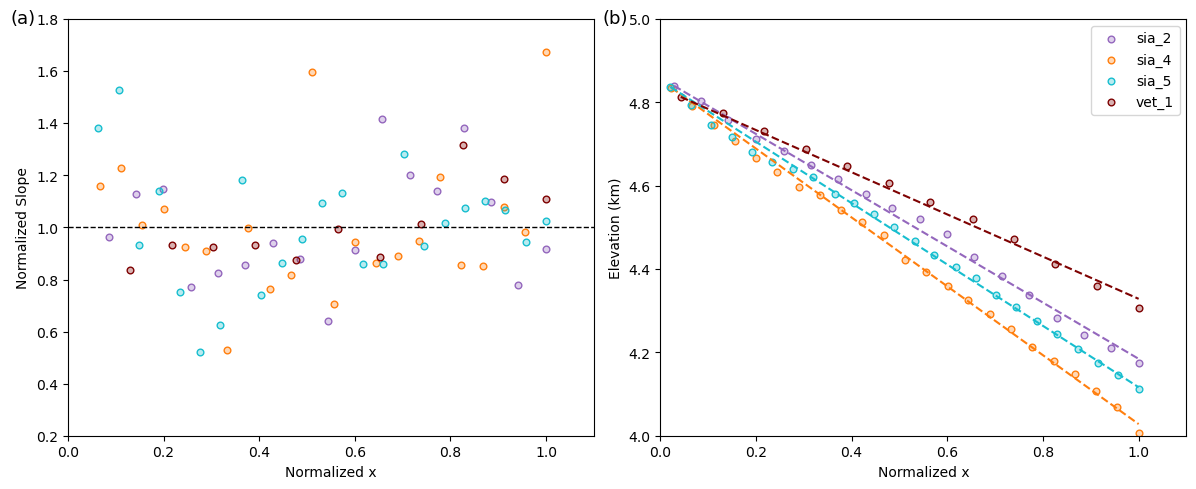

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
i_line = np.linspace(0, 1.1, 100)

# (a) Normalized slope  S / beta'_1  vs  x / x_max
ax[0].plot(i_line, np.ones_like(i_line), "k--", linewidth=1)
for df, group, label, color, marker, trend in constant_streams:
    ss = df.attrs["seg_stats"].dropna(subset=["slope_l"])
    x  = ss["Distance"].values
    sl = ss["slope_l"].values
    b1 = df.attrs["beta'1"]
    ax[0].scatter(x / x.max(), sl / b1, ec=color, fc=fc(color), s=23, label=label)
ax[0].set(xlabel="Normalized x", ylabel="Normalized Slope", xlim=(0,1.1), ylim=(0.2,1.8))
ax[0].text(-0.11, 0.99, "(a)", fontsize=13, transform=ax[0].transAxes)

# (b) Elevation profiles with beta'_2 fit
for df, group, label, color, marker, trend in constant_streams:
    ss = df.attrs["seg_stats"]
    x  = ss["Distance"].values
    z  = ss["elevation"].values

    # add 4000 m to Veteranbreen elevation so it appears in the plot range
    if label == "vet_1":
        z  = z + 4000
        zp = df.attrs["z_pred"] + 4000
    else:
        zp = df.attrs["z_pred"]

    ax[1].scatter(x / x.max(), z * 0.001, ec=color, fc=fc(color), s=23, label=label)
    ax[1].plot(x[:len(zp)] / x.max(), zp[:len(x)] * 0.001, color=color, linestyle="--")

ax[1].set(xlabel="Normalized x", ylabel="Elevation (km)", xlim=(0,1.1), ylim=(4.0,5))
ax[1].text(-0.11, 0.99, "(b)", fontsize=13, transform=ax[1].transAxes)
ax[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig2_ab.pdf", dpi=600, bbox_inches="tight")
plt.show()

## Fig 3 ab — Upward trend: normalized slope & elevation

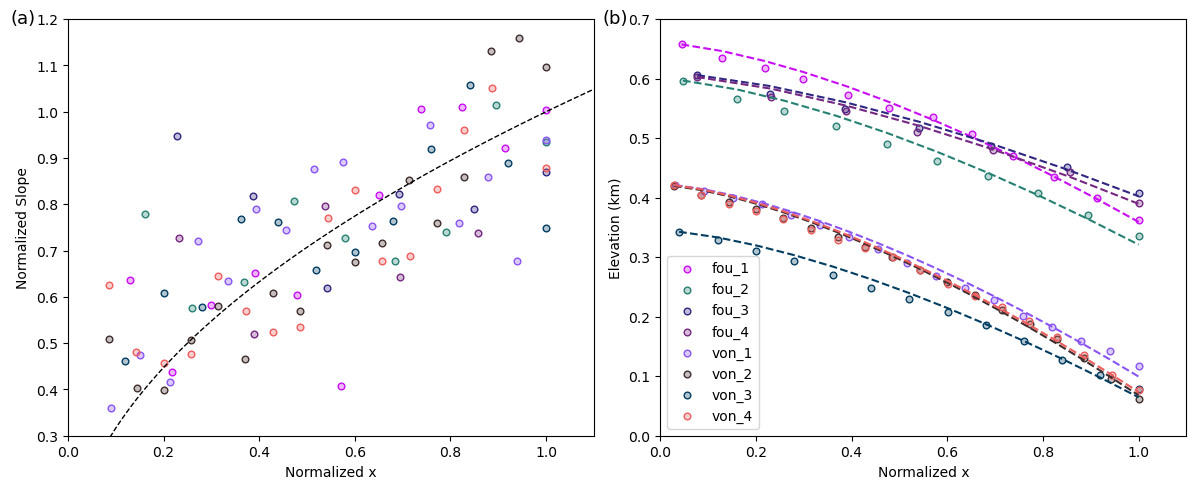

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
i_line = np.linspace(0, 1.1, 100)
ax[0].plot(i_line, i_line**0.5, "k--", linewidth=1)

for df, group, label, color, marker, trend in upward_streams:
    ss    = df.attrs["seg_stats"].dropna(subset=["slope_l"])
    x     = ss["Distance"].values
    sl    = ss["slope_l"].values
    b1    = df.attrs["beta'1"]
    x_max = x.max()
    ax[0].scatter(x / x_max, sl / (b1 * x_max**0.5), ec=color, fc=fc(color), s=23, label=label)

    ss_all = df.attrs["seg_stats"]
    xa  = ss_all["Distance"].values
    z   = ss_all["elevation"].values
    zp  = df.attrs["z_pred"]
    ax[1].scatter(xa / xa.max(), z * 0.001, ec=color, fc=fc(color), s=23, label=label)
    ax[1].plot(xa[:len(zp)] / xa.max(), zp[:len(xa)] * 0.001, color=color, linestyle="--")

ax[0].set(xlabel="Normalized x", ylabel="Normalized Slope", xlim=(0,1.1), ylim=(0.3,1.2))
ax[0].text(-0.11, 0.99, "(a)", fontsize=13, transform=ax[0].transAxes)
ax[1].set(xlabel="Normalized x", ylabel="Elevation (km)", xlim=(0,1.1), ylim=(0,0.7))
ax[1].text(-0.11, 0.99, "(b)", fontsize=13, transform=ax[1].transAxes)
ax[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig3_ab.pdf", dpi=600, bbox_inches="tight")
plt.show()


## Fig 3 cd — Downward trend: normalized slope & elevation

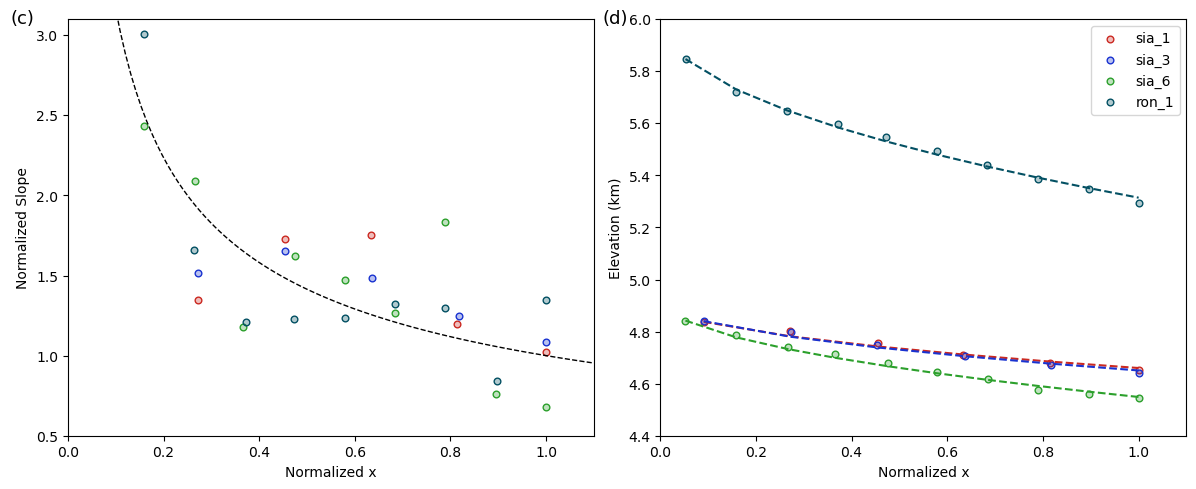

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
i_line = np.linspace(0.01, 1.1, 100)
ax[0].plot(i_line, i_line**-0.5, "k--", linewidth=1)

for df, group, label, color, marker, trend in downward_streams:
    ss    = df.attrs["seg_stats"].dropna(subset=["slope_l"])
    x     = ss["Distance"].values
    sl    = ss["slope_l"].values
    b1    = df.attrs["beta'1"]
    x_max = x.max()
    ax[0].scatter(x / x_max, sl / (b1 * x_max**-0.5), ec=color, fc=fc(color), s=23, label=label)

    ss_all = df.attrs["seg_stats"]
    xa  = ss_all["Distance"].values
    z   = ss_all["elevation"].values
    zp  = df.attrs["z_pred"]
    ax[1].scatter(xa / xa.max(), z * 0.001, ec=color, fc=fc(color), s=23, label=label)
    ax[1].plot(xa[:len(zp)] / xa.max(), zp[:len(xa)] * 0.001, color=color, linestyle="--")

ax[0].set(xlabel="Normalized x", ylabel="Normalized Slope", xlim=(0,1.1), ylim=(0.5,3.1))
ax[0].text(-0.11, 0.99, "(c)", fontsize=13, transform=ax[0].transAxes)
ax[1].set(xlabel="Normalized x", ylabel="Elevation (km)", xlim=(0,1.1), ylim=(4.4,6.0))
ax[1].text(-0.11, 0.99, "(d)", fontsize=13, transform=ax[1].transAxes)
ax[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig3_cd.pdf", dpi=600, bbox_inches="tight")
plt.show()


## Fig 4 ab — Sinuosity along stream & observed vs predicted

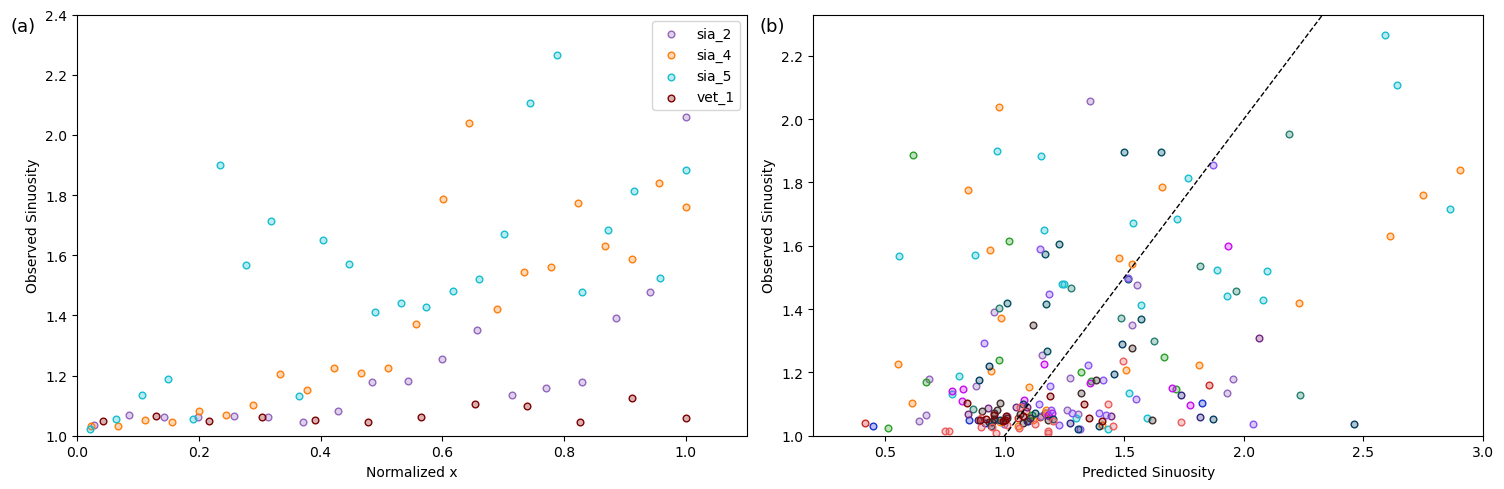

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.2, 1.2]})

# (a) Sinuosity spatial pattern — constant-trend streams
for df, group, label, color, marker, trend in constant_streams:
    ss = df.attrs["seg_stats"]
    ax[0].scatter(ss["Distance"] / ss["Distance"].max(), ss["sinuosity"],
                  ec=color, fc=fc(color), s=23, marker=marker, label=label)
ax[0].set(xlabel="Normalized x", ylabel="Observed Sinuosity", xlim=(0,1.1), ylim=(1,2.4))
ax[0].text(-0.10, 0.96, "(a)", fontsize=13, transform=ax[0].transAxes)
ax[0].legend()

# (b) Observed vs Predicted sinuosity (all streams, using beta'_1)
line = np.linspace(0, 3, 100)
ax[1].plot(line, line, "k--", linewidth=1, label="1:1 line")
for df, group, label, color, marker, trend in stream_registry:
    ss       = df.attrs["seg_stats"]
    sin_obs  = ss["sinuosity"].values
    sin_pred = df.attrs["sin_pred"]
    n = min(len(sin_obs), len(sin_pred))
    ax[1].scatter(sin_pred[:n], sin_obs[:n], ec=color, fc=fc(color), s=23, label=label)
ax[1].set(xlabel="Predicted Sinuosity", ylabel="Observed Sinuosity",
          xlim=(0.2,3), ylim=(1,2.33))
ax[1].text(-0.08, 0.96, "(b)", fontsize=13, transform=ax[1].transAxes)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "Fig4_ab.pdf", dpi=600, bbox_inches="tight")
plt.show()


  Stream       r     R²  p-value
   sia_1  0.8911 0.7941 0.017131
   sia_2  0.2483 0.0616 0.320524
   sia_3  0.9389 0.8815 0.005486
   sia_4  0.4409 0.1944 0.035239
   sia_5  0.4208 0.1771 0.040605
   sia_6 -0.2601 0.0677 0.467920
   ron_1  0.1819 0.0331 0.615045
   fou_1  0.1939 0.0376 0.546019
   fou_2 -0.0868 0.0075 0.811561
   fou_3  0.1281 0.0164 0.784229
   fou_4  0.2963 0.0878 0.518829
   von_1  0.1543 0.0238 0.554337
   von_2  0.0218 0.0005 0.931680
   von_3 -0.1776 0.0315 0.561583
   von_4  0.1231 0.0151 0.626637
   vet_1  0.0946 0.0089 0.769961
COMBINED  0.2570 0.0660 0.000160


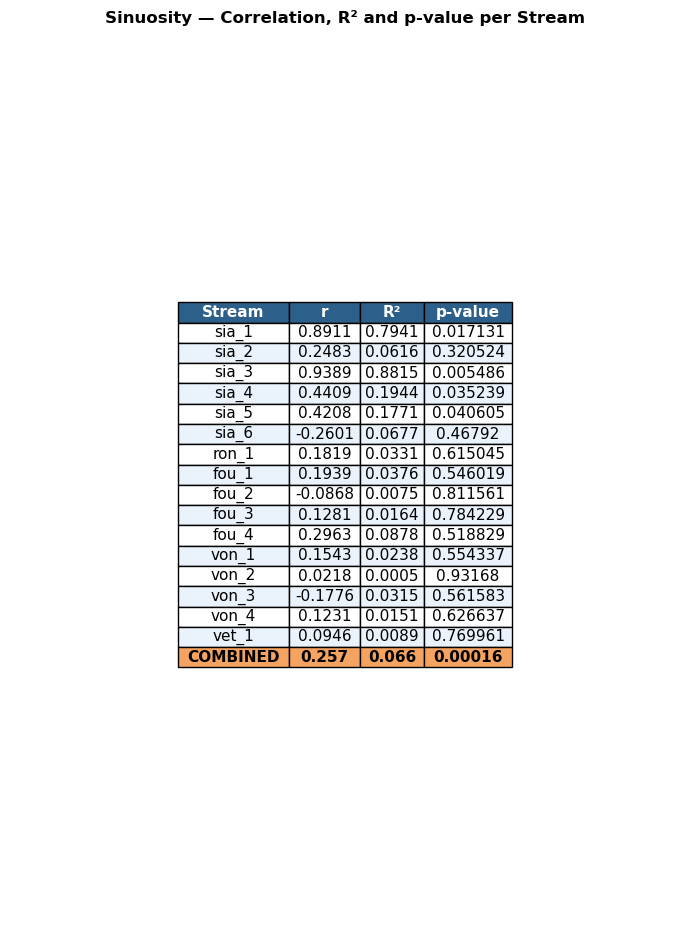

Saved: Output/sinuosity_correlation.pdf


In [72]:
from scipy import stats as scipy_stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rows = []
all_obs_pool  = []
all_pred_pool = []

for entry in stream_registry:
    df, group, label, color, marker, trend = entry
    ss       = df.attrs["seg_stats"]
    sin_obs  = ss["sinuosity"].values
    sin_pred = df.attrs["sin_pred"]
    n        = min(len(sin_obs), len(sin_pred))

    obs  = sin_obs[:n]
    pred = sin_pred[:n]

    mask = np.isfinite(obs) & np.isfinite(pred)
    obs, pred = obs[mask], pred[mask]

    if len(obs) < 2:
        continue

    # R² as square of Pearson r
    r, p_val = scipy_stats.pearsonr(obs, pred)
    r2       = r ** 2

    rows.append({
        "Stream":  label,
        "r":       round(r,     4),
        "R²":      round(r2,    4),
        "p-value": round(p_val, 6),
    })

    all_obs_pool.extend(obs)
    all_pred_pool.extend(pred)

# ── combined ─────────────────────────────────────────────────────────
all_obs_pool  = np.array(all_obs_pool)
all_pred_pool = np.array(all_pred_pool)

r_all, p_all = scipy_stats.pearsonr(all_obs_pool, all_pred_pool)
r2_all       = r_all ** 2

rows.append({
    "Stream":  "COMBINED",
    "r":       round(r_all,  4),
    "R²":      round(r2_all, 4),
    "p-value": round(p_all,  6),
})

corr_df = pd.DataFrame(rows)
print(corr_df.to_string(index=False))

# ── render as table and save to PDF ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, len(corr_df) * 0.5 + 1))
ax.axis("off")

table = ax.table(
    cellText  = corr_df.values,
    colLabels = corr_df.columns,
    cellLoc   = "center",
    loc       = "center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(corr_df.columns))))

for col_idx in range(len(corr_df.columns)):
    table[(0, col_idx)].set_facecolor("#2c5f8a")
    table[(0, col_idx)].set_text_props(color="white", fontweight="bold")

for row_idx in range(1, len(corr_df)):
    fc_row = "#eaf2fb" if row_idx % 2 == 0 else "white"
    for col_idx in range(len(corr_df.columns)):
        table[(row_idx, col_idx)].set_facecolor(fc_row)

for col_idx in range(len(corr_df.columns)):
    table[(len(corr_df), col_idx)].set_facecolor("#f4a460")
    table[(len(corr_df), col_idx)].set_text_props(fontweight="bold")

plt.title("Sinuosity — Correlation, R² and p-value per Stream",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()

pdf_path = OUTPUT_DIR + "sinuosity_correlation.pdf"
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {pdf_path}")

  Stream       r     R²  p-value
   sia_1  0.8911 0.7941 0.017131
   sia_2  0.2483 0.0616 0.320524
   sia_3  0.9389 0.8815 0.005486
   sia_4  0.4409 0.1944 0.035239
   sia_5  0.4208 0.1771 0.040605
   sia_6 -0.2601 0.0677 0.467920
   ron_1  0.1819 0.0331 0.615045
   fou_1  0.1939 0.0376 0.546019
   fou_2 -0.0868 0.0075 0.811561
   fou_3  0.1281 0.0164 0.784229
   fou_4  0.2963 0.0878 0.518829
   von_1  0.1543 0.0238 0.554337
   von_2  0.0218 0.0005 0.931680
   von_3 -0.1776 0.0315 0.561583
   von_4  0.1231 0.0151 0.626637
   vet_1  0.0946 0.0089 0.769961
COMBINED  0.2570 0.0660 0.000160


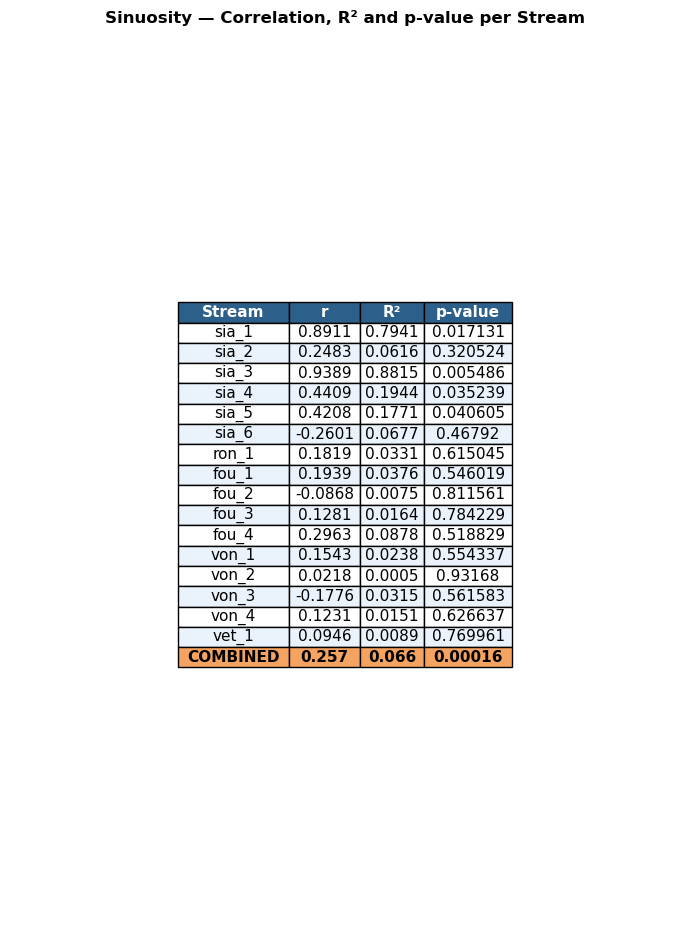

Saved: Output/sinuosity_correlation.pdf


In [71]:
from scipy import stats as scipy_stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rows = []
all_obs_pool  = []
all_pred_pool = []

for entry in stream_registry:
    df, group, label, color, marker, trend = entry
    ss       = df.attrs["seg_stats"]
    sin_obs  = ss["sinuosity"].values
    sin_pred = df.attrs["sin_pred"]
    n        = min(len(sin_obs), len(sin_pred))

    obs  = sin_obs[:n]
    pred = sin_pred[:n]

    mask = np.isfinite(obs) & np.isfinite(pred)
    obs, pred = obs[mask], pred[mask]

    if len(obs) < 2:
        continue

    # method 5 — scipy linregress
    slope, intercept, r, p_val, se = scipy_stats.linregress(obs, pred)
    r2 = r ** 2

    rows.append({
        "Stream":  label,
        "r":       round(r,     4),
        "R²":      round(r2,    4),
        "p-value": round(p_val, 6),
    })

    all_obs_pool.extend(obs)
    all_pred_pool.extend(pred)

# ── combined across all streams ───────────────────────────────────────
all_obs_pool  = np.array(all_obs_pool)
all_pred_pool = np.array(all_pred_pool)

slope_all, intercept_all, r_all, p_all, se_all = scipy_stats.linregress(
    all_obs_pool, all_pred_pool)
r2_all = r_all ** 2

rows.append({
    "Stream":  "COMBINED",
    "r":       round(r_all,  4),
    "R²":      round(r2_all, 4),
    "p-value": round(p_all,  6),
})

corr_df = pd.DataFrame(rows)
print(corr_df.to_string(index=False))

# ── render as table and save to PDF ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, len(corr_df) * 0.5 + 1))
ax.axis("off")

table = ax.table(
    cellText  = corr_df.values,
    colLabels = corr_df.columns,
    cellLoc   = "center",
    loc       = "center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(corr_df.columns))))

# header styling
for col_idx in range(len(corr_df.columns)):
    table[(0, col_idx)].set_facecolor("#2c5f8a")
    table[(0, col_idx)].set_text_props(color="white", fontweight="bold")

# alternating row colors
for row_idx in range(1, len(corr_df)):
    fc_row = "#eaf2fb" if row_idx % 2 == 0 else "white"
    for col_idx in range(len(corr_df.columns)):
        table[(row_idx, col_idx)].set_facecolor(fc_row)

# combined row highlight
for col_idx in range(len(corr_df.columns)):
    table[(len(corr_df), col_idx)].set_facecolor("#f4a460")
    table[(len(corr_df), col_idx)].set_text_props(fontweight="bold")

plt.title("Sinuosity — Correlation, R² and p-value per Stream",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()

pdf_path = OUTPUT_DIR + "sinuosity_correlation.pdf"
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {pdf_path}")

In [61]:
from scipy import stats as scipy_stats
from sklearn.metrics import r2_score
import numpy as np

# ── pool observed and predicted sinuosity across all streams ─────────
all_obs  = []
all_pred = []

for entry in stream_registry:
    df, group, label, color, marker, trend = entry
    ss       = df.attrs["seg_stats"]
    sin_obs  = ss["sinuosity"].values
    sin_pred = df.attrs["sin_pred"]
    n        = min(len(sin_obs), len(sin_pred))

    all_obs.extend(sin_obs[:n])
    all_pred.extend(sin_pred[:n])

all_obs  = np.array(all_obs)
all_pred = np.array(all_pred)

# remove NaN
mask     = np.isfinite(all_obs) & np.isfinite(all_pred)
all_obs, all_pred = all_obs[mask], all_pred[mask]

r, p_val = scipy_stats.pearsonr(all_obs, all_pred)
r2       = r2_score(all_obs, all_pred)

print(f"{'Metric':<12}  {'Value':>10}")
print("-" * 26)
print(f"{'r':<12}  {r:>10.4f}")
print(f"{'R²':<12}  {r2:>10.4f}")
print(f"{'p-value':<12}  {p_val:>10.6f}")
print(f"{'n (total)':<12}  {len(all_obs):>10d}")

Metric             Value
--------------------------
r                 0.2570
R²               -4.3091
p-value         0.000160
n (total)            211


## Fig S5 — Elevation profiles per glacier group

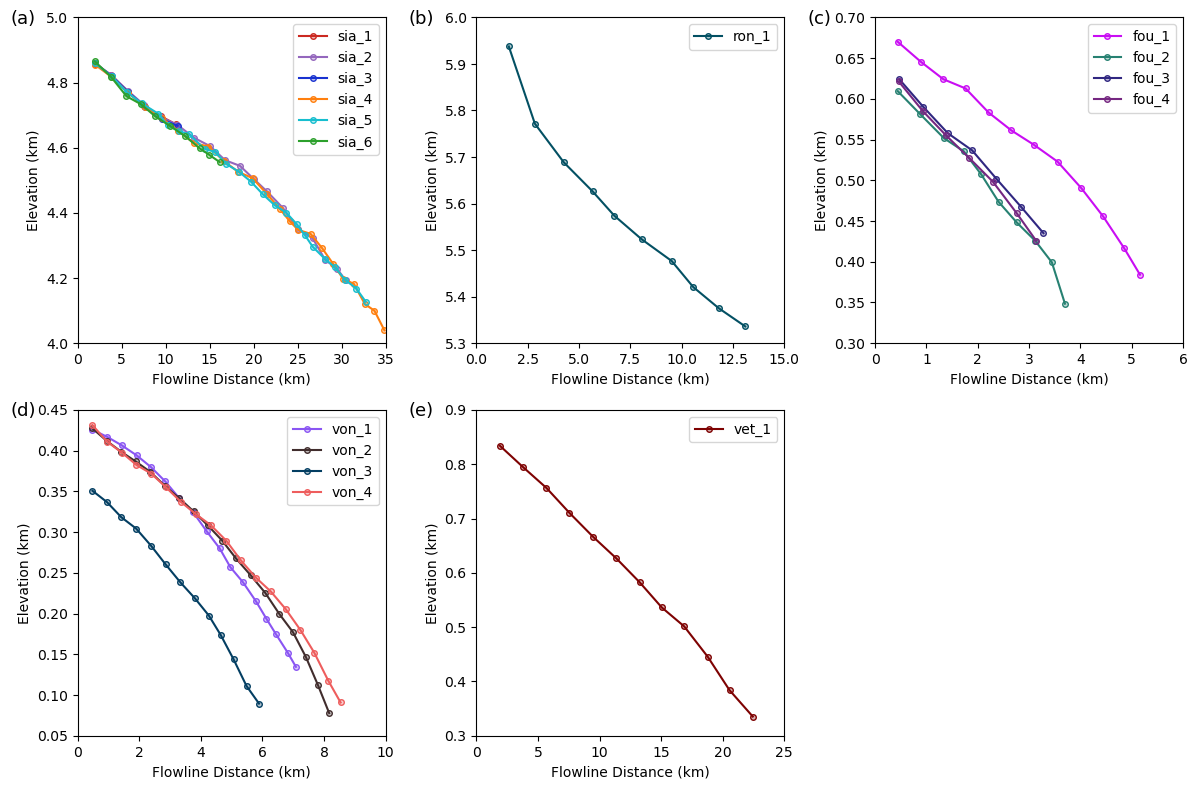

In [62]:
group_order  = ["Siachen", "Rongbuk", "Fountain", "Vonbreen", "Veteranbreen"]
xlims        = [(0,35), (0,15), (0,6), (0,10), (0,25)]
ylims        = [(4.0,5.0), (5.3,6.0), (0.30,0.70), (0.05,0.45), (0.3,0.9)]
panel_labels = list("abcde")

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
axes = ax.flatten()

for idx, group_name in enumerate(group_order):
    axi = axes[idx]
    for df, group, label, color, marker, trend in group_subsets.get(group_name, []):
        ss = df.attrs["seg_stats"]
        x  = ss["Acc_Norm"].values * 0.001
        z  = ss["elevation_max"].values * 0.001    # offset already applied in loading
        axi.plot(x[:len(z)], z[:len(x)], marker=marker, markeredgecolor=color,
                 markerfacecolor=fc(color), markersize=4, color=color, label=label)
    axi.set(xlim=xlims[idx], xlabel="Flowline Distance (km)", ylabel="Elevation (km)")
    if ylims[idx]:
        axi.set_ylim(ylims[idx])
    axi.text(-0.22, 0.98, f"({panel_labels[idx]})", fontsize=13, transform=axi.transAxes)
    axi.legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "FigS5_abcde.pdf", dpi=600, bbox_inches="tight")
plt.show()


## Fig S7 — Flux profiles per glacier group

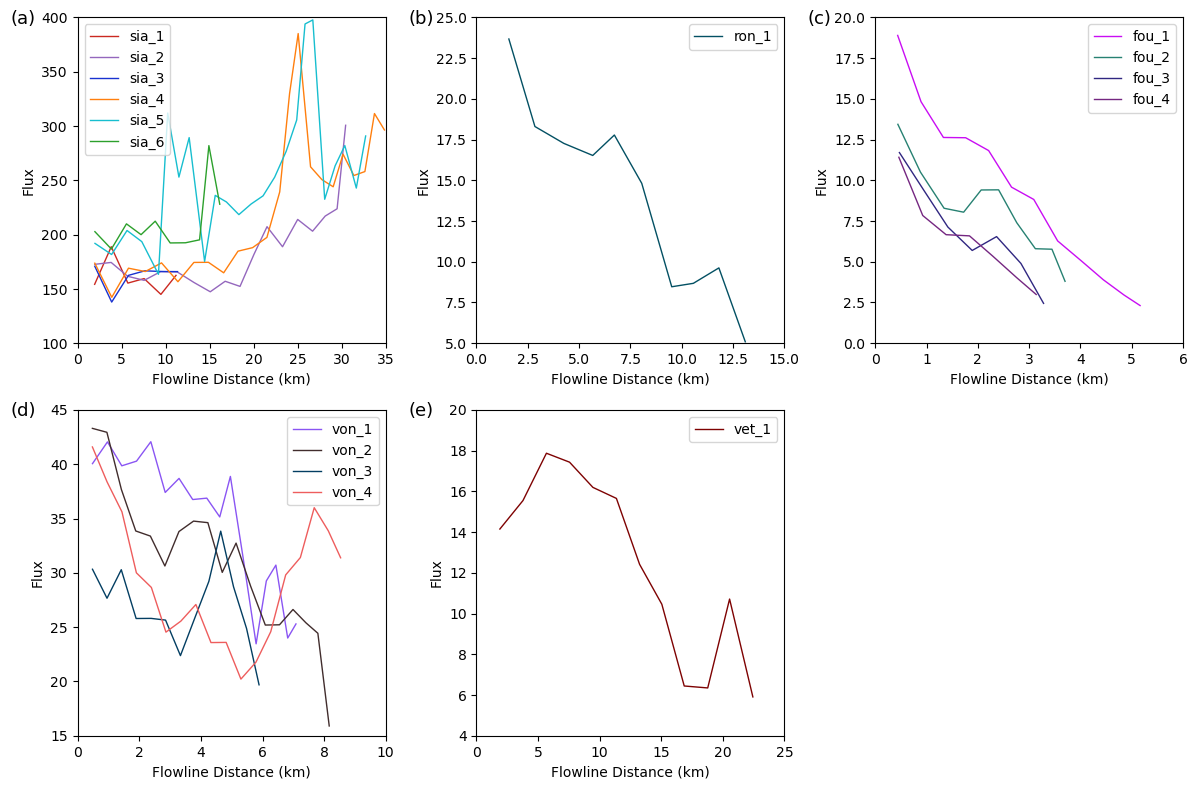

In [63]:
ylims_flux = [(100,400), (5,25), (0,20), (15,45), (4,20)]

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
axes = ax.flatten()

for idx, group_name in enumerate(group_order):
    axi = axes[idx]
    for df, group, label, color, marker, trend in group_subsets.get(group_name, []):
        ss = df.attrs["seg_stats"]
        axi.plot(ss["Acc_Norm"] * 0.001, ss["flux"],
                 color=color, linewidth=1, label=label)
    axi.set(xlim=xlims[idx], ylim=ylims_flux[idx],
            xlabel="Flowline Distance (km)", ylabel="Flux")
    axi.text(-0.22, 0.98, f"({panel_labels[idx]})", fontsize=13, transform=axi.transAxes)
    axi.legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "FigS7_abcde.pdf", dpi=600, bbox_inches="tight")
plt.show()


## Fig S8 — Sinuosity & slope KDE

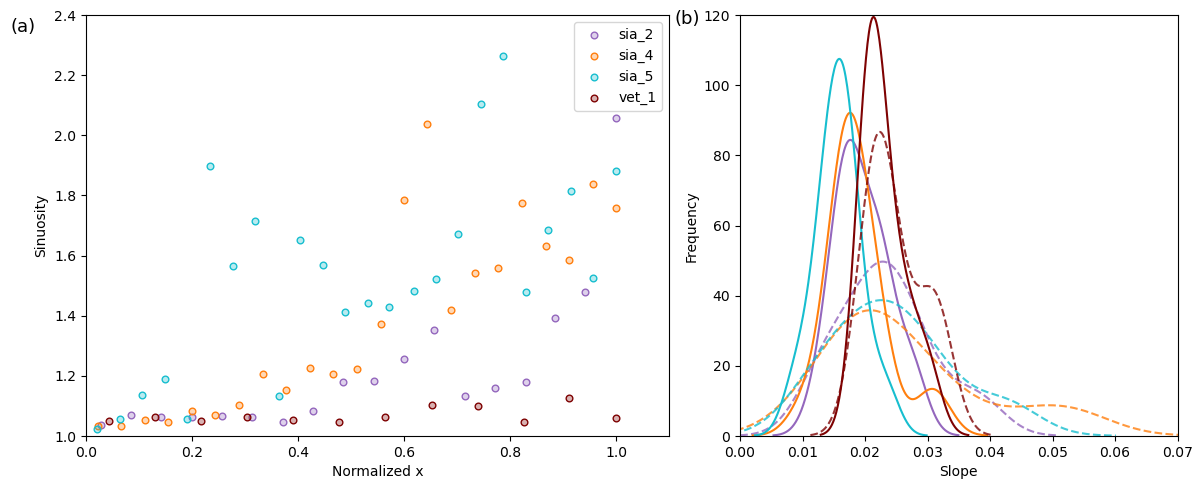

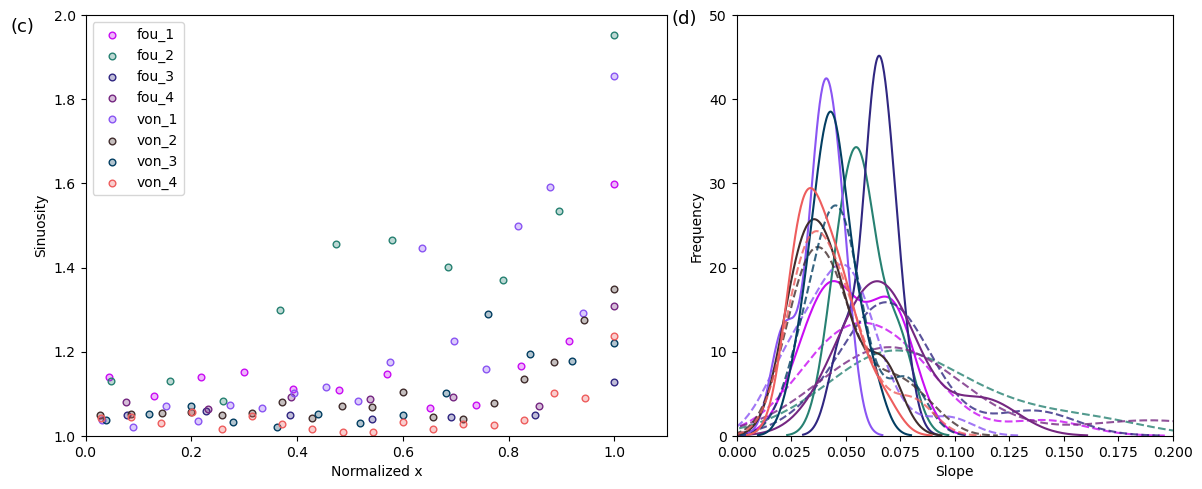

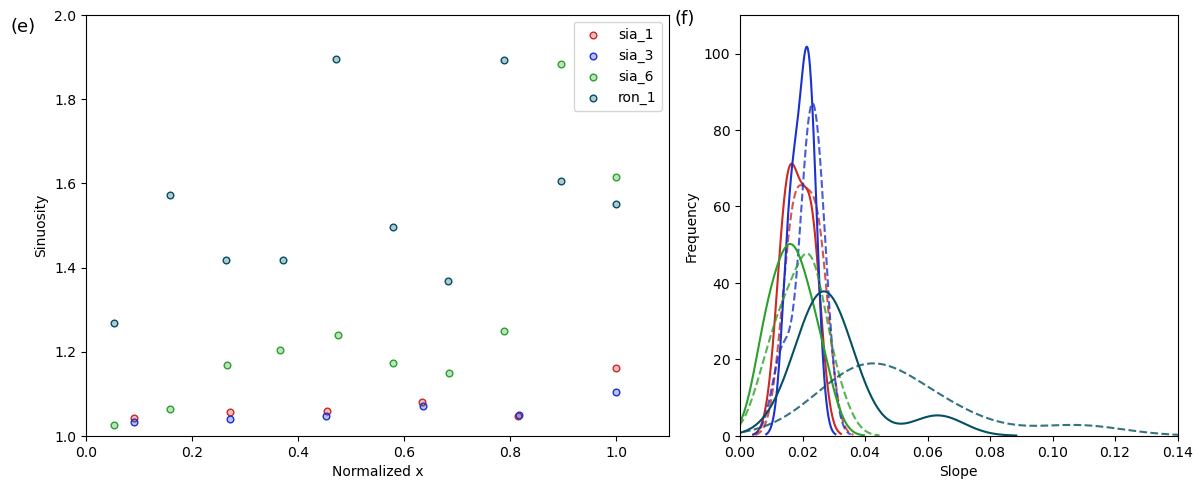

In [64]:
# FigS6_ab — constant trend
regime_configs = [
    (constant_streams,  ("a","b"), (0.07, 120), (1,2.4), "FigS8_ab.pdf"),
    (upward_streams,    ("c","d"), (0.20,  50), (1,2.0), "FigS8_cd.pdf"),
    (downward_streams,  ("e","f"), (0.14,  110), (1,2.0), "FigS8_ef.pdf"),
]

for group_entries, panels, (xlim_sl, ylim_sl), (xlimit, ylimit), fname in regime_configs:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.2, 0.9]})
    for df, group, label, color, marker, trend in group_entries:
        ss     = df.attrs["seg_stats"]
        x_norm = ss["Distance"] / ss["Distance"].max()
        ax[0].scatter(x_norm, ss["sinuosity"], ec=color, fc=fc(color),
                      s=23, marker=marker, label=label)
        sns.kdeplot(ss["slope_l"], linestyle="-",  color=color, ax=ax[1], common_norm=False)
        sns.kdeplot(ss["slope_d"], linestyle="--", color=color, ax=ax[1],
                    common_norm=False, alpha=0.8)
    ax[0].set(xlabel="Normalized x", ylabel="Sinuosity", xlim=(0,1.1), ylim=(xlimit, ylimit))
    ax[0].text(-0.13, 0.96, f"({panels[0]})", fontsize=13, transform=ax[0].transAxes)
    ax[0].legend()
    ax[1].set(xlabel="Slope", ylabel="Frequency", xlim=(0, xlim_sl), ylim=(0, ylim_sl))
    ax[1].text(-0.15, 0.98, f"({panels[1]})", fontsize=13, transform=ax[1].transAxes)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + fname, dpi=600, bbox_inches="tight")
    plt.show()
